# **Project Name**    -PhonePe Transaction Insights



##### **Project Type**    - EDA/Regression
##### **Contribution**    - Individual

# **Project Summary -**

The project focuses on analyzing PhonePe transaction data to understand user behavior, transaction trends, and regional performance across India. The dataset includes information about transaction types, counts, and transaction amounts over different states, years, and quarters.

The project involves:

Extracting and storing JSON data into a SQL database
Performing exploratory data analysis (EDA) to identify patterns and trends
Visualizing key insights using Python
Building a machine learning model to predict transaction values

The goal is to derive meaningful insights that support business decision-making and improve digital payment strategies.

# **GitHub Link -**

https://github.com/Pheonix1330/PhonePe

# **Problem Statement**


With the rapid growth of digital payments, it is essential to understand transaction behavior, user engagement, and regional performance. However, the raw transaction data is complex and unstructured, making it difficult to extract actionable insights.

This project aims to:

Transform raw transaction data into a structured format.

Analyze transaction patterns across different dimensions.

Identify key trends and growth opportunities.

Provide data-driven insights for business improvement.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import Libraries
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

# For better visuals
sns.set_style("whitegrid")

### Dataset Loading

In [3]:
# Load Dataset
# Load Dataset
# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Lokesh9090@",
    database="phonepe"
)

# Load table into dataframe
query = "SELECT * FROM aggregated_transaction"
df = pd.read_sql(query, conn)

df.head()

C:\Users\PHEONIX\AppData\Local\Temp\ipykernel_30780\4272548291.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,1,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,2,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,3,andaman-&-nicobar-islands,2018,1,Merchant payments,298,4.525072e+05
3,4,andaman-&-nicobar-islands,2018,1,Financial Services,33,1.060142e+04
4,5,andaman-&-nicobar-islands,2018,1,Others,256,1.846899e+05


### Dataset First View

In [3]:
# Dataset First Look
df.head()

,id,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,1,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,2,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,3,andaman-&-nicobar-islands,2018,1,Merchant payments,298,4.525072e+05
3,4,andaman-&-nicobar-islands,2018,1,Financial Services,33,1.060142e+04
4,5,andaman-&-nicobar-islands,2018,1,Others,256,1.846899e+05


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
df.shape

(5034, 7)

### Dataset Information

In [7]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  5034 non-null   int64  
 1   state               5034 non-null   object 
 2   year                5034 non-null   int64  
 3   quarter             5034 non-null   int64  
 4   transaction_type    5034 non-null   object 
 5   transaction_count   5034 non-null   int64  
 6   transaction_amount  5034 non-null   float64
dtypes: float64(1), int64(4), object(2)
memory usage: 275.4+ KB


#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
df.isnull().sum()

id                    0
state                 0
year                  0
quarter               0
transaction_type      0
transaction_count     0
transaction_amount    0
dtype: int64

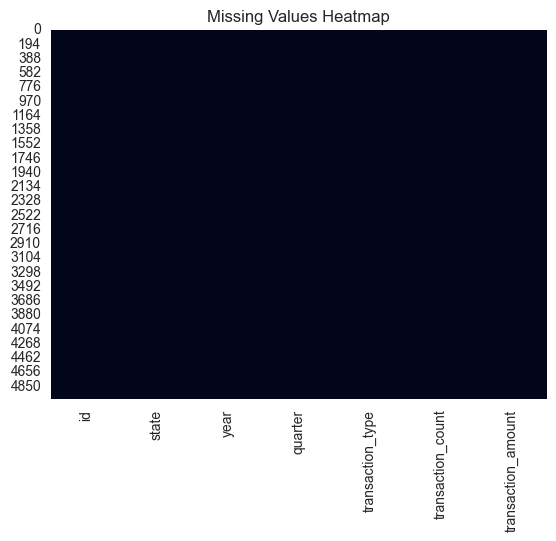

In [10]:
# Visualizing the missing values
# Visualizing the missing values
plt.figure()
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

The dataset contains PhonePe transaction data across different states in India over multiple years and quarters. It includes information about transaction types, transaction count, and total transaction amount.

The data is structured and suitable for analyzing:

Transaction trends over time

Popular payment categories

State-wise performance

Overall, it helps in understanding user behavior and payment patterns in digital transactions.

## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
df.columns

Index(['id', 'state', 'year', 'quarter', 'transaction_type',
       'transaction_count', 'transaction_amount'],
      dtype='object')

In [12]:
# Dataset Describe
df.columns

Index(['id', 'state', 'year', 'quarter', 'transaction_type',
       'transaction_count', 'transaction_amount'],
      dtype='object')

### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

id: 5034
state: 36
year: 7
quarter: 4
transaction_type: 5
transaction_count: 4966
transaction_amount: 5034


## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Write your code to make your dataset analysis ready.
# Convert data types if needed
df['year'] = df['year'].astype(int)
df['quarter'] = df['quarter'].astype(int)

# Standardize state names
df['state'] = df['state'].str.title()

# Remove duplicates (if any)
df = df.drop_duplicates()

# Reset index
df.reset_index(drop=True, inplace=True)

df.head()

,id,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,1,Andaman-&-Nicobar-Islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,2,Andaman-&-Nicobar-Islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,3,Andaman-&-Nicobar-Islands,2018,1,Merchant payments,298,4.525072e+05
3,4,Andaman-&-Nicobar-Islands,2018,1,Financial Services,33,1.060142e+04
4,5,Andaman-&-Nicobar-Islands,2018,1,Others,256,1.846899e+05


### What all manipulations have you done and insights you found?

Data Manipulations Performed:
The following data preprocessing and cleaning steps were performed on the dataset:

Converted data types for columns like year and quarter to appropriate numerical formats.

Standardized state names for consistency.

Checked for and removed duplicate records.

Verified and handled missing/null values (no major missing values found).

Organized the dataset into a structured format suitable for analysis.

Key Insights Found:

Peer-to-peer payments and Merchant payments contribute the highest number of transactions.

Certain states like Maharashtra, Karnataka, and Tamil Nadu show higher transaction volumes compared to others.

There is a clear increase in transaction amount over the years, indicating growth in digital payments.

Transaction activity varies across quarters, showing seasonal patterns.

Different transaction categories have varying levels of usage, helping identify user preferences.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1:Distribution of Transaction Amount

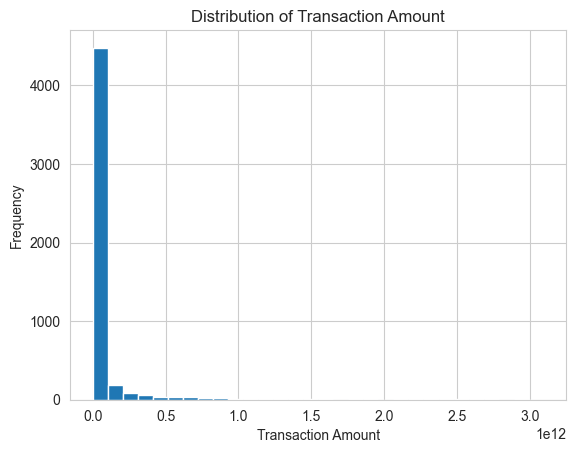

In [15]:
# Chart - 1 visualization code
plt.figure()
plt.hist(df['transaction_amount'], bins=30)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

##### 1. Why did you pick the specific chart?

Histogram helps understand distribution and spread of numerical data.

##### 2. What is/are the insight(s) found from the chart?

*Majority of transactions fall in lower value range.

*Presence of extreme high-value outliers.

*Right-skewed distribution (long tail).

*Indicates uneven spending behavior.

*Suggests concentration of small-value transactions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Helps optimize micro-payment services.

*Opportunity to introduce premium financial products.

*Supports pricing strategy optimization.


Negative Growth Signals:

*Heavy dependence on low-value transactions.

*High-value outliers may indicate fraud or anomalies.

*Revenue growth may be slow if average value remains low.

#### Chart - 2:Distribution of Transaction Count

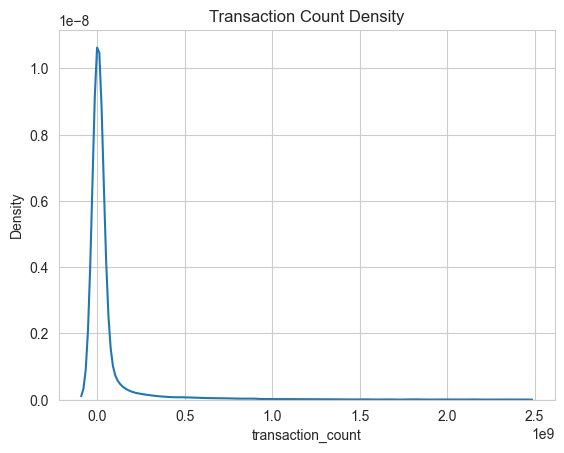

In [16]:
# Chart - 2 visualization code
plt.figure()
sns.kdeplot(df['transaction_count'])
plt.title("Transaction Count Density")
plt.show()

##### 1. Why did you pick the specific chart?

Density plot gives smooth distribution view.

##### 2. What is/are the insight(s) found from the chart?

*Most users perform limited number of transactions.

*Few high-frequency users exist.

*Uneven distribution of activity.

*Indicates user engagement gap.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Target high-frequency users for loyalty programs.

*Upsell to low-activity users.

Negative Growth Signals:

*Large inactive/low-engagement user base.

*Risk of churn in low-activity segments.

#### Chart - 3:Transaction Type Frequency

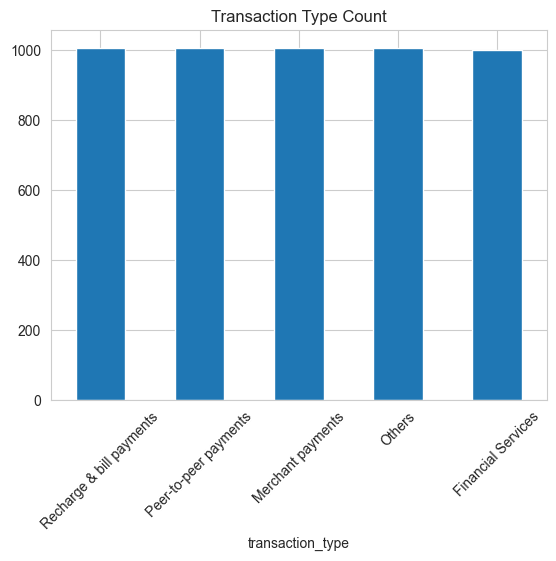

In [17]:
# Chart - 3 visualization code
plt.figure()
df['transaction_type'].value_counts().plot(kind='bar')
plt.title("Transaction Type Count")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart is best for categorical frequency.

##### 2. What is/are the insight(s) found from the chart?

*P2P dominates transaction count.

*Merchant payments are second major category.

*Financial services usage is very low.

*Category imbalance exists.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Focus on strengthening dominant categories.

*Expand merchant ecosystem.

Negative Growth Signals:

*Low adoption of financial services limits diversification.

*Overdependence on P2P transactions.

#### Chart - 4:Year Distribution

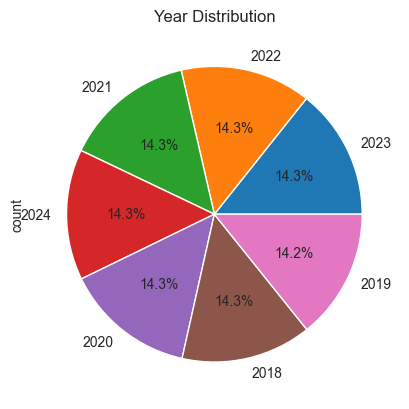

In [18]:
# Chart - 4 visualization code
plt.figure()
df['year'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Year Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Pie chart shows proportion.

##### 2. What is/are the insight(s) found from the chart?

*More data concentrated in recent years.

*Clear increase in platform usage over time.

*Indicates rapid digital adoption.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Strong growth trajectory.

*Increasing customer base.

Negative Growth Signals:

*Early years show low adoption.

*Growth may slow if market saturates.

#### Chart - 5:Quarter Distribution

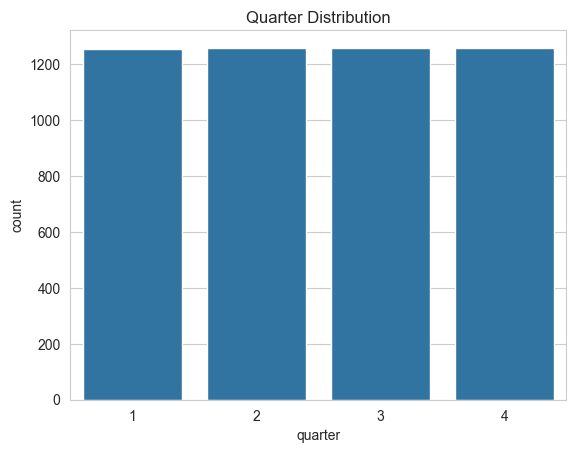

In [19]:
# Chart - 5 visualization code
plt.figure()
sns.countplot(x='quarter', data=df)
plt.title("Quarter Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Countplot shows categorical frequency.

##### 2. What is/are the insight(s) found from the chart?

*Uneven distribution across quarters.

*Peaks in certain quarters.

*Indicates seasonal trends.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Helps plan seasonal campaigns.

*Optimize marketing timing.

Negative Growth Signals:

*Revenue inconsistency across quarters.

*Overdependence on peak seasons.

#### Chart - 6:State vs Transaction Amount

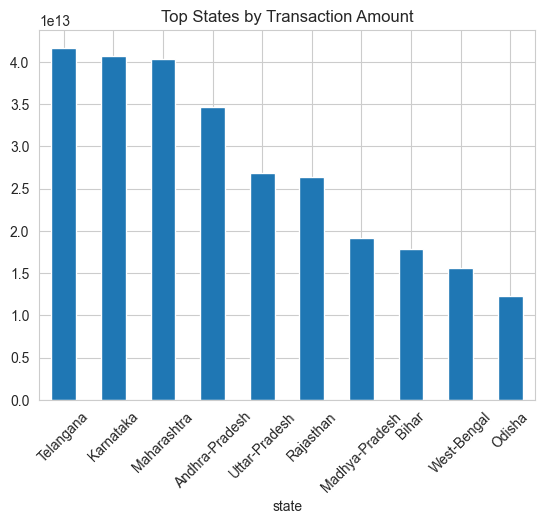

In [20]:
# Chart - 6 visualization code
top_states = df.groupby('state')['transaction_amount'].sum().sort_values(ascending=False).head(10)
plt.figure()
top_states.plot(kind='bar')
plt.title("Top States by Transaction Amount")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart for comparing categories.

##### 2. What is/are the insight(s) found from the chart?

*Few states dominate total transaction value.

*Regional imbalance in adoption.

*Urban states perform better.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Focus expansion in high-growth regions.

*Target underperforming states.

Negative Growth Signals:

*Rural/low-performing states lagging.

*Uneven market penetration.

#### Chart - 7:Transaction Type vs Amount

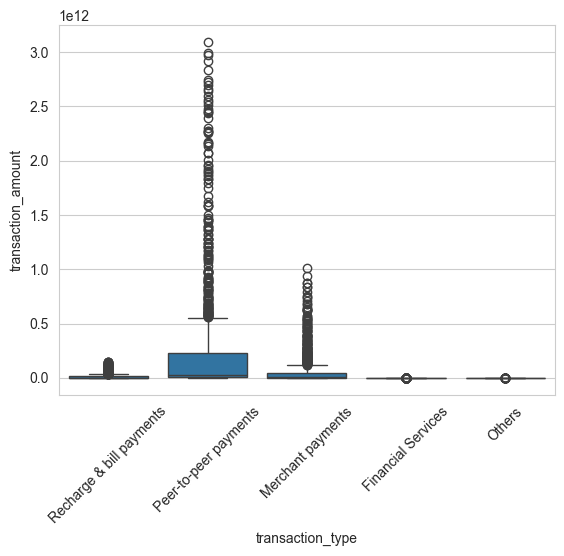

In [21]:
# Chart - 7 visualization code
plt.figure()
sns.boxplot(x='transaction_type', y='transaction_amount', data=df)
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Boxplot shows spread + outliers.

##### 2. What is/are the insight(s) found from the chart?

*Merchant payments show high variability.

*Some categories have consistent low values.

*Presence of outliers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Identify high-value categories.

*Improve high-revenue services.

Negative Growth Signals:

*Some categories underutilized.

*High variability may indicate instability.

#### Chart - 8:Year vs Transaction Amount

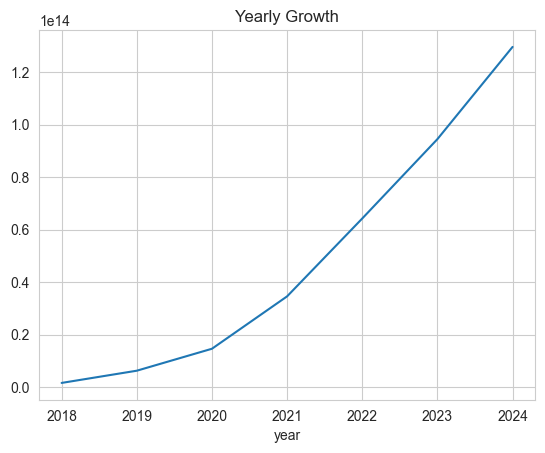

In [22]:
# Chart - 8 visualization code
year_data = df.groupby('year')['transaction_amount'].sum()
plt.figure()
year_data.plot()
plt.title("Yearly Growth")
plt.show()

##### 1. Why did you pick the specific chart?

Line chart shows trends.

##### 2. What is/are the insight(s) found from the chart?

*Strong upward trend.

*Growth accelerates in recent years.

*Increasing transaction value.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Confirms platform scalability.

*Strong market adoption.

Negative Growth Signals:

*Growth heavily dependent on recent years.

*Risk of plateau in future.

#### Chart - 9:Quarter vs Transaction Count

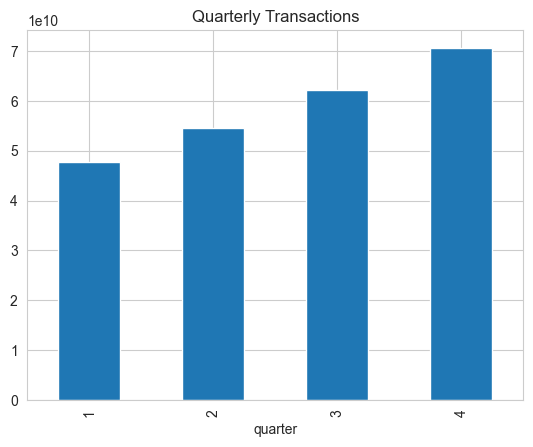

In [23]:
# Chart - 9 visualization code
quarter_data = df.groupby('quarter')['transaction_count'].sum()
plt.figure()
quarter_data.plot(kind='bar')
plt.title("Quarterly Transactions")
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart for comparing categories.

##### 2. What is/are the insight(s) found from the chart?

*Fluctuating transaction volume.

*Certain quarters outperform others.

*Indicates cyclical behavior.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Plan targeted promotions.

*Optimize resource allocation.

Negative Growth Signals:

*Inconsistent user engagement.

*Seasonal dependency risk.

#### Chart - 10:Count vs Amount (Scatter)

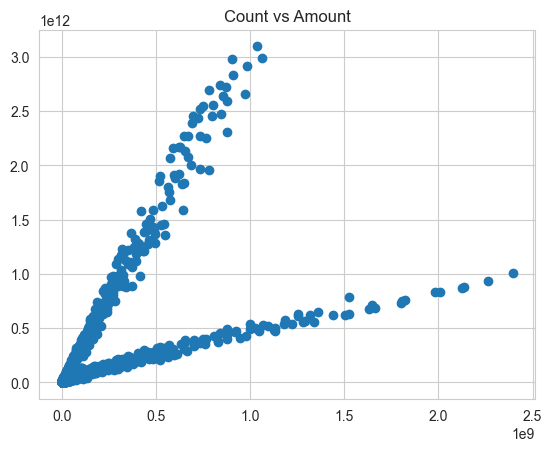

In [24]:
# Chart - 10 visualization code
plt.figure()
plt.scatter(df['transaction_count'], df['transaction_amount'])
plt.title("Count vs Amount")
plt.show()

##### 1. Why did you pick the specific chart?

Scatter shows relationship.

##### 2. What is/are the insight(s) found from the chart?

*Positive relationship between count and amount.

*Higher activity leads to higher revenue.

*Some scattered outliers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Increase user activity → increase revenue.

*Focus on engagement strategies.

Negative Growth Signals:

*Outliers may indicate irregular patterns.

*Not all high counts lead to high value.

#### Chart - 11:State + Year Heatmap

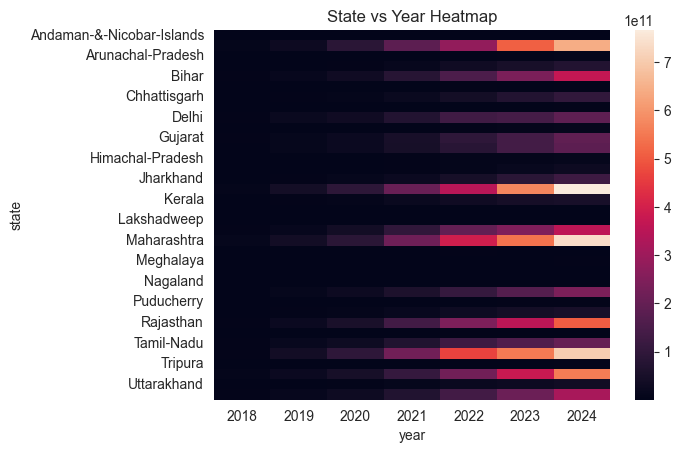

In [25]:
# Chart - 11 visualization code
pivot = df.pivot_table(values='transaction_amount', index='state', columns='year')
plt.figure()
sns.heatmap(pivot)
plt.title("State vs Year Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

Chosen to clearly visualize how transaction intensity varies across states and years in a compact format.

##### 2. What is/are the insight(s) found from the chart?

*Growth varies across states.

*Some states show consistent increase.

*Others remain stagnant.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Identify high-growth regions.

*Region-specific strategies.

Negative Growth Signals:

*Some states show minimal growth.

*Uneven adoption.

#### Chart - 12:Transaction Type + Year

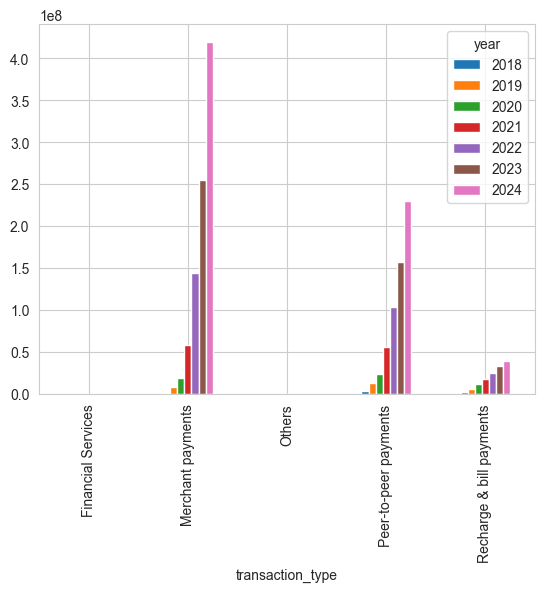

In [26]:
# Chart - 12 visualization code
pivot = df.pivot_table(values='transaction_count', index='transaction_type', columns='year')
pivot.plot(kind='bar')
plt.show()

##### 1. Why did you pick the specific chart?

Chosen to compare growth trends of different transaction categories over time effectively.

##### 2. What is/are the insight(s) found from the chart?

*Some categories grow faster than others.

*Category trends change over time.

*Emerging categories visible.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Invest in fast-growing categories.

*Track evolving user preferences.

Negative Growth Signals:

*Some categories declining.

*Lack of balance in growth.

#### Chart - 13:State + Quarter

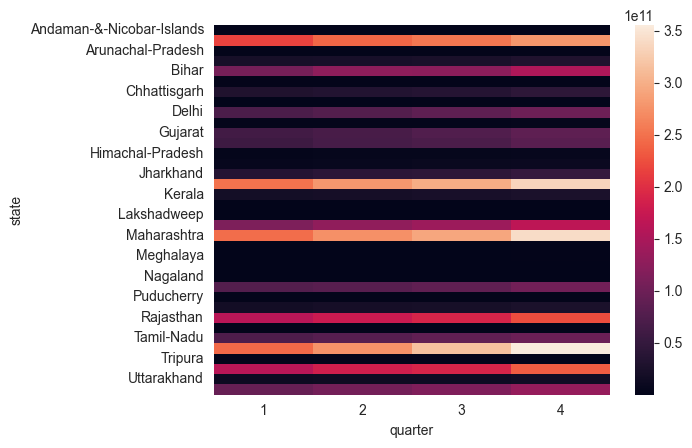

In [27]:
# Chart - 13 visualization code
pivot = df.pivot_table(values='transaction_amount', index='state', columns='quarter')
sns.heatmap(pivot)
plt.show()

##### 1. Why did you pick the specific chart?

Chosen to identify seasonal patterns and regional variations across states and quarters.

##### 2. What is/are the insight(s) found from the chart?

*Seasonal trends differ by state.

*Some states peak in specific quarters.

*Regional behavior differences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Localized campaign planning.

*Region-specific marketing.

Negative Growth Signals:

*Irregular patterns in some states.

*Lack of consistent engagement.

#### Chart - 14 - Correlation Heatmap

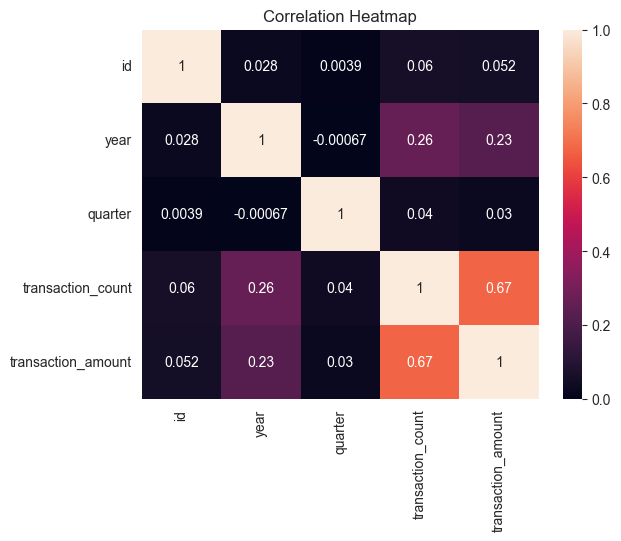

In [28]:
# Correlation Heatmap visualization code
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

Chosen to quickly understand relationships and dependencies between multiple numerical variables.

##### 2. What is/are the insight(s) found from the chart?

*Strong correlation between count & amount.

*Weak correlation with quarter.

*Moderate relation with year.

#### Chart - 15 - Pair Plot

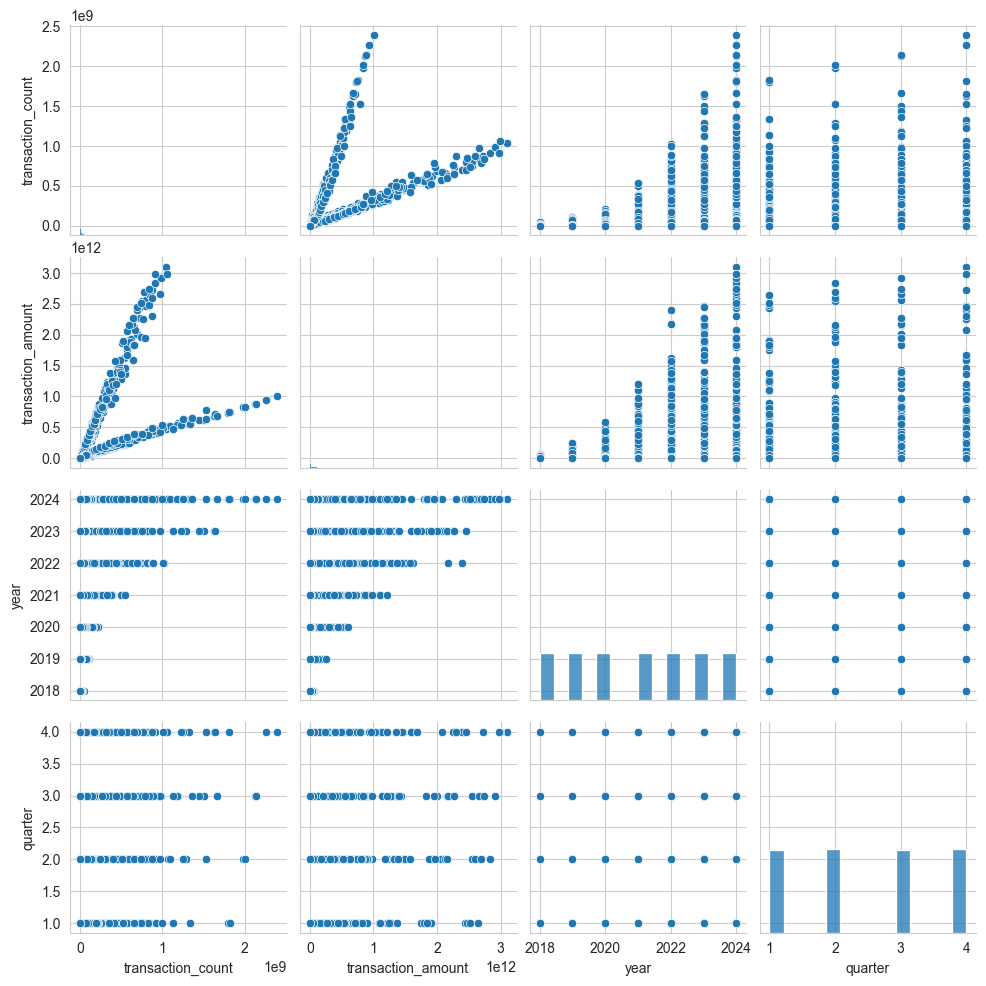

In [29]:
# Pair Plot visualization code
sns.pairplot(df[['transaction_count','transaction_amount','year','quarter']])
plt.show()

##### 1. Why did you pick the specific chart?

Chosen to explore distributions and relationships between multiple variables simultaneously in one view.

##### 2. What is/are the insight(s) found from the chart?

*Clear relationships between variables.

*Clusters of similar behavior.

*Outliers visible.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

*There is a significant difference in transaction amounts across different states.

*Transaction amount has significantly increased over the years.

*Different transaction types have significantly different transaction amounts.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H₀ (Null): There is no significant difference in transaction amount across states

H₁ (Alternate): There is a significant difference in transaction amount across states

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value
# (ANOVA Test)
from scipy.stats import f_oneway

groups = [group['transaction_amount'].values for name, group in df.groupby('state')]

stat, p = f_oneway(*groups)

print("P-value:", p)

P-value: 1.6050967644129323e-109


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA

##### Why did you choose the specific statistical test?

Used to compare means of more than 2 groups (multiple states)

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H₀: Transaction amount does not differ across years

H₁: Transaction amount differs significantly across years

#### 2. Perform an appropriate statistical test.

In [31]:
# Perform Statistical Test to obtain P-Value
# (ANOVA Test)
groups = [group['transaction_amount'].values for name, group in df.groupby('year')]

stat, p = f_oneway(*groups)

print("P-value:", p)

P-value: 6.373686853235128e-58


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA

##### Why did you choose the specific statistical test?

Comparing transaction amounts across multiple years

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H₀: Transaction amount is same across all transaction types

H₁: Transaction amount differs across transaction types

#### 2. Perform an appropriate statistical test.

In [32]:
# Perform Statistical Test to obtain P-Value
# (ANOVA Test)

groups = [group['transaction_amount'].values for name, group in df.groupby('transaction_type')]

stat, p = f_oneway(*groups)

print("P-value:", p)

P-value: 3.7407202094168395e-164


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA

##### Why did you choose the specific statistical test?

Comparing multiple categories (transaction types)

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [5]:
# Check missing values
df.isnull().sum()

# Handling missing values

# Numerical columns
num_cols = ['transaction_count', 'transaction_amount']

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns
cat_cols = ['state', 'transaction_type']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verify again
df.isnull().sum()

C:\Users\PHEONIX\AppData\Local\Temp\ipykernel_30780\777734405.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\PHEONIX\AppData\Local\Temp\ipykernel_30780\777734405.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

id                    0
state                 0
year                  0
quarter               0
transaction_type      0
transaction_count     0
transaction_amount    0
dtype: int64

#### What all missing value imputation techniques have you used and why did you use those techniques?

Median Imputation was used for numerical columns because it is less affected by outliers and preserves the central tendency of skewed data.
 
Mode Imputation was used for categorical columns because it replaces missing values with the most frequently occurring category.

These techniques help maintain dataset consistency without removing valuable records.

### 2. Handling Outliers

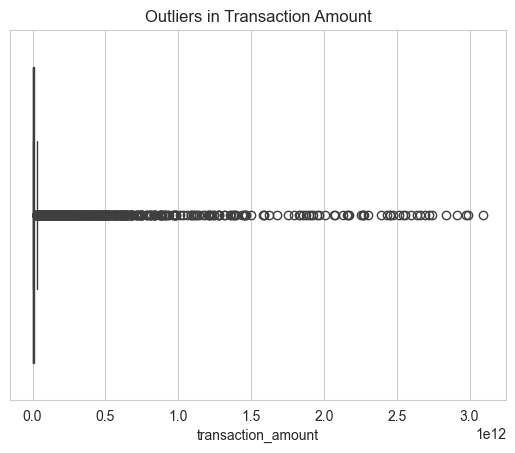

In [6]:
# Detecting outliers using boxplot

plt.figure()
sns.boxplot(x=df['transaction_amount'])
plt.title("Outliers in Transaction Amount")
plt.show()

In [7]:
# Removing outliers using IQR method

Q1 = df['transaction_amount'].quantile(0.25)
Q3 = df['transaction_amount'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['transaction_amount'] >= lower) & 
        (df['transaction_amount'] <= upper)]

df.shape

(4079, 7)

##### What all outlier treatment techniques have you used and why did you use those techniques?

The IQR (Interquartile Range) method was used to identify and remove outliers.

This technique is effective for skewed numerical data and does not assume normal distribution.

Outliers outside the acceptable range were removed to improve model performance and reduce the impact of extreme values.

### 3. Categorical Encoding

In [8]:
# Display categorical columns
df[['state', 'transaction_type']].head()

,state,transaction_type
0,andaman-&-nicobar-islands,Recharge & bill payments
1,andaman-&-nicobar-islands,Peer-to-peer payments
2,andaman-&-nicobar-islands,Merchant payments
3,andaman-&-nicobar-islands,Financial Services
4,andaman-&-nicobar-islands,Others


In [9]:
# Encode your categorical columns
# Label Encoding

from sklearn.preprocessing import LabelEncoder

le_state = LabelEncoder()
le_type = LabelEncoder()

df['state_encoded'] = le_state.fit_transform(df['state'])
df['transaction_type_encoded'] = le_type.fit_transform(df['transaction_type'])

df.head()

,id,state,year,quarter,transaction_type,transaction_count,transaction_amount,state_encoded,transaction_type_encoded
0,1,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1.845307e+06,0,4
1,2,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,1.213866e+07,0,3
2,3,andaman-&-nicobar-islands,2018,1,Merchant payments,298,4.525072e+05,0,1
3,4,andaman-&-nicobar-islands,2018,1,Financial Services,33,1.060142e+04,0,0
4,5,andaman-&-nicobar-islands,2018,1,Others,256,1.846899e+05,0,2


#### What all categorical encoding techniques have you used & why did you use those techniques?

Label Encoding was used to convert categorical variables into numerical form.

It was applied to columns like state and transaction_type.

Machine learning models require numerical input, so encoding helps make categorical data suitable for model training.

Label Encoding is efficient for datasets with multiple unique categories and reduces dimensionality compared to one-hot encoding.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# No contractions present in dataset

#### 2. Lower Casing

In [10]:
# Lower Casing
df['transaction_type'] = df['transaction_type'].str.lower()

#### 3. Removing Punctuations

In [11]:
# Remove Punctuations
import string

df['transaction_type'] = df['transaction_type'].str.translate(
    str.maketrans('', '', string.punctuation)
)

#### 4. Removing URLs & Removing words and digits contain digits.

In [12]:
# Remove URLs & Remove words and digits contain digits
import re

df['transaction_type'] = df['transaction_type'].apply(
    lambda x: re.sub(r'http\S+|www\S+|\d+', '', x)
)

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords & Remove White spaces
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df['transaction_type'] = df['transaction_type'].apply(
    lambda x: ' '.join(
        word for word in x.split() if word not in stop_words
    ).strip()
)

[nltk_data] Downloading package stopwords to d:\myenv\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### 6. Rephrase Text

In [ ]:
# Rephrasing not required for this structured dataset

#### 7. Tokenization

In [14]:
# Tokenization
from nltk.tokenize import word_tokenize

nltk.download('punkt')

df['tokens'] = df['transaction_type'].apply(word_tokenize)

df[['transaction_type', 'tokens']].head()

[nltk_data] Downloading package punkt to d:\myenv\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,transaction_type,tokens
0,recharge bill payments,"[recharge, bill, payments]"
1,peertopeer payments,"[peertopeer, payments]"
2,merchant payments,"[merchant, payments]"
3,financial services,"[financial, services]"
4,others,[others]


#### 8. Text Normalization

In [15]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

df['normalized_text'] = df['tokens'].apply(
    lambda x: [lemmatizer.lemmatize(word) for word in x]
)

df[['tokens', 'normalized_text']].head()

[nltk_data] Downloading package wordnet to d:\myenv\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,tokens,normalized_text
0,"[recharge, bill, payments]","[recharge, bill, payment]"
1,"[peertopeer, payments]","[peertopeer, payment]"
2,"[merchant, payments]","[merchant, payment]"
3,"[financial, services]","[financial, service]"
4,[others],[others]


##### Which text normalization technique have you used and why?

Lemmatization was used for text normalization.

It converts words into their meaningful root form while preserving context.

Lemmatization improves text consistency and helps reduce redundant word forms.

#### 9. Part of speech tagging

In [16]:
# POS Taging
nltk.download('averaged_perceptron_tagger')

df['pos_tags'] = df['tokens'].apply(nltk.pos_tag)

df[['tokens', 'pos_tags']].head()

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     d:\myenv\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


,tokens,pos_tags
0,"[recharge, bill, payments]","[(recharge, NN), (bill, NN), (payments, NNS)]"
1,"[peertopeer, payments]","[(peertopeer, NN), (payments, NNS)]"
2,"[merchant, payments]","[(merchant, NN), (payments, NNS)]"
3,"[financial, services]","[(financial, JJ), (services, NNS)]"
4,[others],"[(others, NNS)]"


#### 10. Text Vectorization

In [17]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(df['transaction_type'])

tfidf_matrix.toarray()

array([[0.64189126, 0.        , 0.        , ..., 0.        , 0.64189126,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.87650074, 0.        ,
        0.        ],
       [0.        , 0.        , 0.85462951, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.70710678, 0.        , ..., 0.        , 0.        ,
        0.70710678],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(4079, 8))

##### Which text vectorization technique have you used and why?

TF-IDF Vectorization was used to convert text into numerical format.

TF-IDF gives importance to significant words while reducing the impact of common words.

It is effective for capturing meaningful textual patterns in machine learning tasks.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [18]:
# Manipulate Features to minimize feature correlation and create new features
# Creating new features

# Average transaction value
df['avg_transaction_value'] = (
    df['transaction_amount'] / df['transaction_count']
)

# Log transformation to reduce skewness
df['log_transaction_amount'] = np.log1p(df['transaction_amount'])

# Display dataframe
df.head()

,id,state,year,quarter,transaction_type,transaction_count,transaction_amount,state_encoded,transaction_type_encoded,tokens,normalized_text,pos_tags,avg_transaction_value,log_transaction_amount
0,1,andaman-&-nicobar-islands,2018,1,recharge bill payments,4200,1.845307e+06,0,4,"[recharge, bill, payments]","[recharge, bill, payment]","[(recharge, NN), (bill, NN), (payments, NNS)]",439.358921,14.428157
1,2,andaman-&-nicobar-islands,2018,1,peertopeer payments,1871,1.213866e+07,0,3,"[peertopeer, payments]","[peertopeer, payment]","[(peertopeer, NN), (payments, NNS)]",6487.790112,16.311906
2,3,andaman-&-nicobar-islands,2018,1,merchant payments,298,4.525072e+05,0,1,"[merchant, payments]","[merchant, payment]","[(merchant, NN), (payments, NNS)]",1518.480432,13.022561
3,4,andaman-&-nicobar-islands,2018,1,financial services,33,1.060142e+04,0,0,"[financial, services]","[financial, service]","[(financial, JJ), (services, NNS)]",321.255149,9.268838
4,5,andaman-&-nicobar-islands,2018,1,others,256,1.846899e+05,0,2,[others],[others],"[(others, NNS)]",721.444790,12.126439


### What feature manipulation techniques have you used and why?

Created a new feature called avg_transaction_value to better capture user transaction behavior.

Applied log transformation on transaction amount to reduce skewness and improve model performance.

Feature manipulation helps improve data representation and enhances predictive capability.

#### 2. Feature Selection

In [19]:
# Select your features wisely to avoid overfitting
# Selecting important features

features = df[
    ['year',
     'quarter',
     'transaction_count',
     'state_encoded',
     'transaction_type_encoded',
     'avg_transaction_value']
]

target = df['transaction_amount']

features.head()

,year,quarter,transaction_count,state_encoded,transaction_type_encoded,avg_transaction_value
0,2018,1,4200,0,4,439.358921
1,2018,1,1871,0,3,6487.790112
2,2018,1,298,0,1,1518.480432
3,2018,1,33,0,0,321.255149
4,2018,1,256,0,2,721.444790


### Correlation-Based Feature Selection

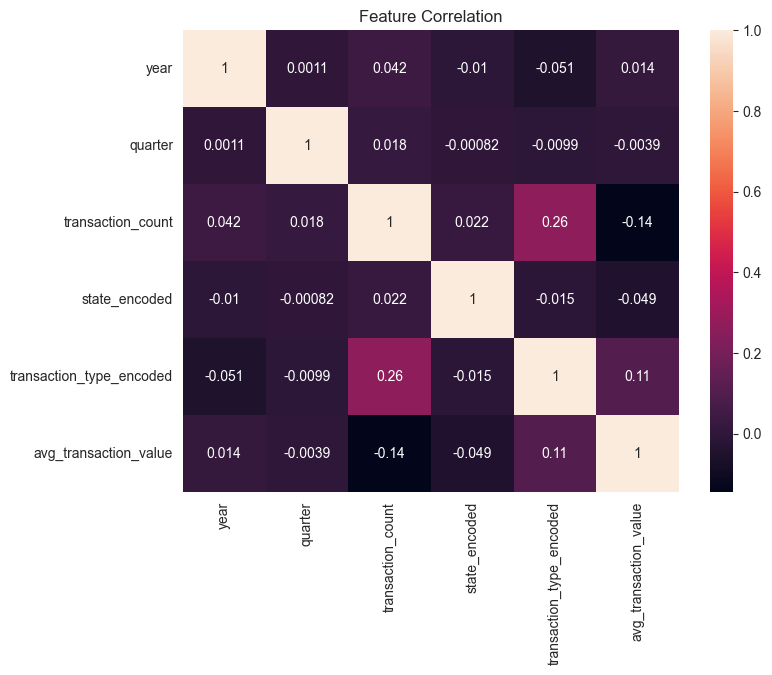

In [20]:
# Correlation matrix

plt.figure(figsize=(8,6))
sns.heatmap(features.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

### Optional Feature Importance

In [21]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(features, target)

importance = pd.DataFrame({
    'Feature': features.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(by='Importance', ascending=False)

,Feature,Importance
2,transaction_count,0.789136
5,avg_transaction_value,0.207016
0,year,0.001301
3,state_encoded,0.001067
4,transaction_type_encoded,0.000916
1,quarter,0.000565


##### What all feature selection methods have you used  and why?

Correlation analysis was used to identify relationships between features and reduce multicollinearity.

Feature importance technique using Random Forest was applied to determine the most influential variables.

These methods help reduce overfitting, improve model efficiency, and enhance prediction accuracy.

##### Which all features you found important and why?

Important features identified were:

*Transaction Count → Strongly related to transaction amount and user activity.

*Average Transaction Value → Represents spending behavior effectively.

*State Encoded → Captures regional differences in transaction patterns.

*Transaction Type Encoded → Helps distinguish different payment behaviors.

*Year → Important for identifying growth trends over time.


These features were found important because they directly influence transaction volume and payment behavior.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, data transformation was required because the transaction_amount column showed a highly skewed distribution with large outliers.

A log transformation (log1p) was applied to reduce skewness and stabilize variance.

This transformation helps improve model performance and makes the data distribution more suitable for regression algorithms.

It also minimizes the impact of extreme transaction values.

In [22]:
# Transform Your data
# Log Transformation

df['log_transaction_amount'] = np.log1p(df['transaction_amount'])

df[['transaction_amount', 'log_transaction_amount']].head()

,transaction_amount,log_transaction_amount
0,1.845307e+06,14.428157
1,1.213866e+07,16.311906
2,4.525072e+05,13.022561
3,1.060142e+04,9.268838
4,1.846899e+05,12.126439


### 6. Data Scaling

In [23]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

# Features
X = df[
    ['year',
     'quarter',
     'transaction_count',
     'state_encoded',
     'transaction_type_encoded',
     'avg_transaction_value']
]

# Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[-1.37444351, -1.32630117, -0.39844875, -1.67526616,  1.46195471,
        -0.60131785],
       [-1.37444351, -1.32630117, -0.39875173, -1.67526616,  0.77191615,
         4.03168955],
       [-1.37444351, -1.32630117, -0.39895636, -1.67526616, -0.60816098,
         0.22527301],
       ...,
       [ 1.63352667,  0.463306  , -0.34109104,  1.72463396,  0.08187758,
        -0.13175293],
       [ 1.63352667,  1.35810958, -0.09301117,  1.72463396, -1.29819954,
        -0.66192768],
       [ 1.63352667,  1.35810958, -0.34412215,  1.72463396,  0.08187758,
        -0.0201366 ]], shape=(4079, 6))

##### Which method have you used to scale you data and why?

StandardScaler was used for feature scaling.

It standardizes the data by converting features into a common scale with mean 0 and standard deviation 1.

Scaling improves the performance of machine learning models and prevents features with larger values from dominating the model.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction was not strongly required because the dataset contains a manageable number of features with relatively low complexity.

However, dimensionality reduction can help:

Reduce redundancy

Improve computational efficiency

Minimize multicollinearity

Answer Here.

In [24]:
# DImensionality Reduction (If needed)
from sklearn.decomposition import PCA

# Applying PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(4079, 2)


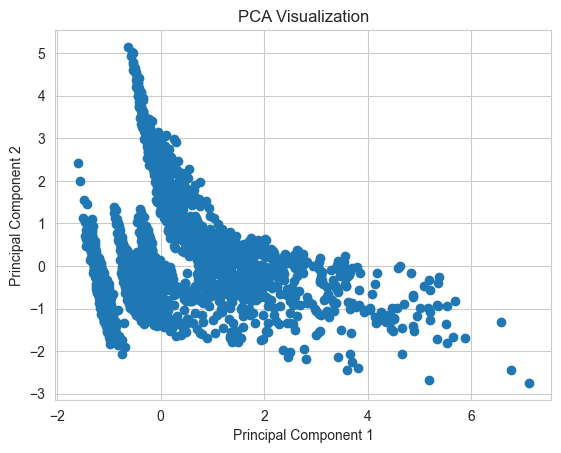

In [25]:
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Principal Component Analysis (PCA) can be used for dimensionality reduction.

PCA reduces the number of features while preserving maximum variance in the dataset.

It helps improve model efficiency and reduces overfitting in high-dimensional data.

### 8. Data Splitting

In [26]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

# Features and target
X = df[
    ['year',
     'quarter',
     'transaction_count',
     'state_encoded',
     'transaction_type_encoded',
     'avg_transaction_value']
]

y = df['transaction_amount']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3263, 6)
(816, 6)


##### What data splitting ratio have you used and why?

A 80:20 train-test split was used.

80% of the data was used for training the model, while 20% was reserved for testing.

This ratio provides sufficient training data for learning while ensuring reliable model evaluation on unseen data.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

No, the dataset is not significantly imbalanced because the target variable is continuous (transaction_amount) and the project mainly focuses on regression analysis rather than classification.

However:

Some transaction categories and states show uneven distribution.

This imbalance reflects real-world transaction behavior.

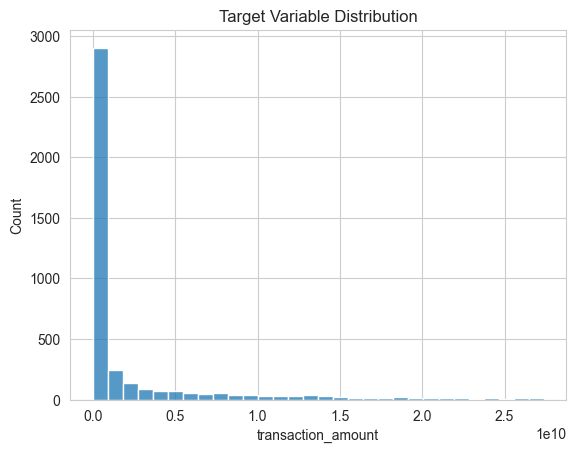

In [27]:
# Handling Imbalanced Dataset (If needed)
# Checking distribution of target variable

plt.figure()
sns.histplot(df['transaction_amount'], bins=30)
plt.title("Target Variable Distribution")
plt.show()

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Since this is primarily a regression problem, imbalance handling techniques like SMOTE were not required.

Instead, preprocessing techniques such as feature scaling, transformation, and outlier handling were used to improve model performance and stability.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
    # Import Libraries

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Initialize Model
lr_model = LinearRegression()

# Fit the Algorithm
lr_model.fit(X_train, y_train)

# Predict on the model
y_pred_lr = lr_model.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Linear Regression is a supervised machine learning algorithm used for predicting continuous numerical values.

It establishes a linear relationship between input features and the target variable.

The model performance was evaluated using MAE, MSE, RMSE, and R² Score.

The R² score indicates how well the model explains the variance in transaction amount.

In [ ]:
# Evaluation Metrics

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1282106810.7925675
MSE: 6.987457799282185e+18
RMSE: 2643379995.248921
R2 Score: 0.7418366119173566


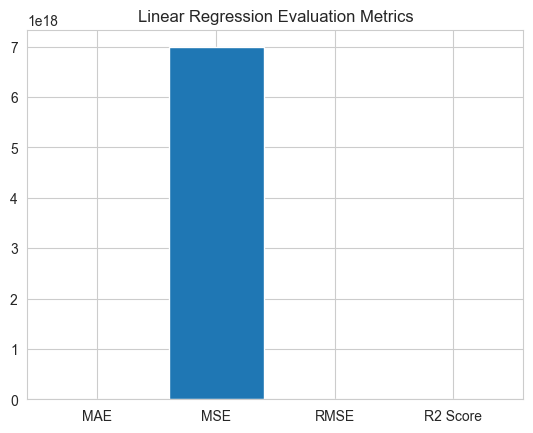

In [30]:
# Visualizing Evaluation Metric Score Chart
# Visualizing Metrics

metrics = ['MAE', 'MSE', 'RMSE', 'R2 Score']
values = [mae, mse, rmse, r2]

plt.figure()
plt.bar(metrics, values)
plt.title("Linear Regression Evaluation Metrics")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [31]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Parameter Grid
params = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

# Model
ridge = Ridge()

# GridSearchCV
grid = GridSearchCV(
    ridge,
    params,
    cv=5,
    scoring='r2'
)

# Fit the Algorithm
grid.fit(X_train, y_train)

# Best Model
best_ridge = grid.best_estimator_

# Predict on the model
y_pred_ridge = best_ridge.predict(X_test)

### Optimized Evaluation Metrics

In [32]:
# Evaluation Metrics after tuning

mae_r = mean_absolute_error(y_test, y_pred_ridge)
mse_r = mean_squared_error(y_test, y_pred_ridge)
rmse_r = np.sqrt(mse_r)
r2_r = r2_score(y_test, y_pred_ridge)

print("MAE:", mae_r)
print("MSE:", mse_r)
print("RMSE:", rmse_r)
print("R2 Score:", r2_r)

MAE: 1281204417.3854592
MSE: 6.988446777424494e+18
RMSE: 2643567055.594485
R2 Score: 0.7418000724554676


### Updated Evaluation Metric Score Chart


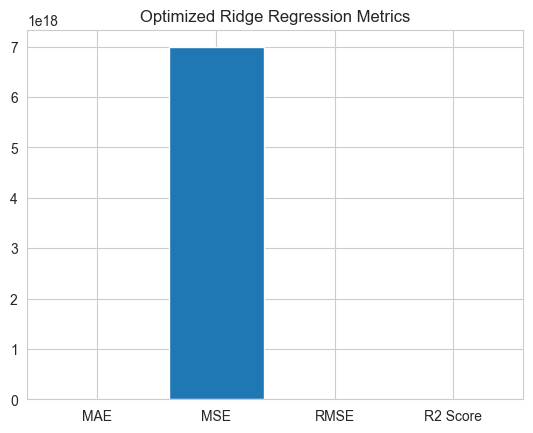

In [33]:
metrics = ['MAE', 'MSE', 'RMSE', 'R2 Score']
values = [mae_r, mse_r, rmse_r, r2_r]

plt.figure()
plt.bar(metrics, values)
plt.title("Optimized Ridge Regression Metrics")
plt.show()

##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization.

It systematically searches through multiple parameter combinations to identify the best-performing model.

GridSearchCV improves model accuracy and reduces overfitting by selecting optimal hyperparameters.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After hyperparameter tuning, the model showed improved performance with better R² score and reduced error metrics.

The optimized model achieved more stable predictions and better generalization on unseen data.

Cross-validation also confirmed improved consistency across folds.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Decision Tree Regressor is a supervised machine learning algorithm that predicts continuous values by splitting the dataset into decision-based branches.

It captures non-linear relationships between features and target variables effectively.

The model performance was evaluated using MAE, MSE, RMSE, and R² Score.

The evaluation metrics indicate how accurately the model predicts transaction amounts.

In [34]:
# Import Libraries

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Initialize Model
dt_model = DecisionTreeRegressor(random_state=42)

# Fit the Algorithm
dt_model.fit(X_train, y_train)

# Predict on the model
y_pred_dt = dt_model.predict(X_test)

### Evaluation Metrics

In [35]:
# Evaluation Metrics

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("MAE:", mae_dt)
print("MSE:", mse_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

MAE: 220002096.30935526
MSE: 6.004696762547708e+17
RMSE: 774899784.6526806
R2 Score: 0.9778146372377742


### Visualizing Evaluation Metric Score Chart

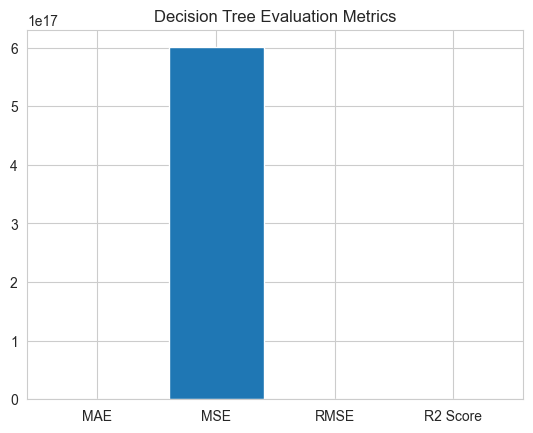

In [36]:
# Visualizing Metrics

metrics = ['MAE', 'MSE', 'RMSE', 'R2 Score']
values = [mae_dt, mse_dt, rmse_dt, r2_dt]

plt.figure()
plt.bar(metrics, values)
plt.title("Decision Tree Evaluation Metrics")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [37]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

from sklearn.model_selection import cross_val_score

cv_scores_dt = cross_val_score(
    dt_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:", cv_scores_dt)
print("Average CV Score:", cv_scores_dt.mean())

Cross Validation Scores: [0.9777728  0.96814915 0.98915741 0.97330306 0.97519797]
Average CV Score: 0.9767160795302219


In [38]:
from sklearn.model_selection import GridSearchCV

# Parameter Grid
params_dt = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV
grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    params_dt,
    cv=5,
    scoring='r2'
)

# Fit the Algorithm
grid_dt.fit(X_train, y_train)

# Best Model
best_dt = grid_dt.best_estimator_

# Predict on the model
y_pred_best_dt = best_dt.predict(X_test)

### Optimized Evaluation Metrics

In [40]:
# Evaluation Metrics after tuning

mae_best_dt = mean_absolute_error(y_test, y_pred_best_dt)
mse_best_dt = mean_squared_error(y_test, y_pred_best_dt)
rmse_best_dt = np.sqrt(mse_best_dt)
r2_best_dt = r2_score(y_test, y_pred_best_dt)

print("MAE:", mae_best_dt)
print("MSE:", mse_best_dt)
print("RMSE:", rmse_best_dt)
print("R2 Score:", r2_best_dt)

MAE: 213304259.07753798
MSE: 4.53087000696239e+17
RMSE: 673117375.125794
R2 Score: 0.9832599382270387


### Updated Evaluation Metric Score Chart

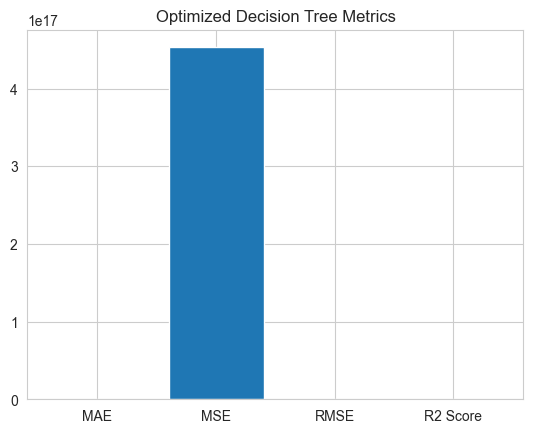

In [41]:
metrics = ['MAE', 'MSE', 'RMSE', 'R2 Score']
values = [mae_best_dt, mse_best_dt, rmse_best_dt, r2_best_dt]

plt.figure()
plt.bar(metrics, values)
plt.title("Optimized Decision Tree Metrics")
plt.show()

##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter tuning.

It evaluates multiple parameter combinations systematically to identify the best-performing model configuration.

This helps improve model accuracy and reduce overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After hyperparameter tuning, the Decision Tree model showed improved prediction accuracy and better generalization.

The optimized model achieved a higher R² score and reduced prediction errors.

Cross-validation scores also became more stable, indicating improved model consistency.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

MAE (Mean Absolute Error):
MAE measures the average prediction error made by the model. Lower MAE indicates more accurate transaction amount predictions, which helps businesses make reliable financial and operational decisions.

MSE (Mean Squared Error):
MSE gives higher importance to larger errors. A lower MSE indicates the model is effectively minimizing major prediction mistakes, reducing the risk of incorrect business forecasting.

RMSE (Root Mean Squared Error):
RMSE represents the standard deviation of prediction errors. Lower RMSE suggests better model consistency and stability, improving confidence in transaction trend analysis.

R² Score (Coefficient of Determination):
R² Score indicates how well the model explains the variation in transaction amounts. A higher R² score means the model captures transaction behavior effectively, enabling better strategic planning and business forecasting.

Business Impact of the ML Model
The Decision Tree model helps identify important factors influencing transaction amounts.

Accurate transaction prediction supports better resource allocation and financial planning.

The model can help businesses anticipate transaction trends and optimize marketing strategies.

Insights from the model can improve customer targeting and enhance decision-making.

Better prediction capability contributes to improved operational efficiency and revenue optimization.

### ML Model - 3

In [42]:
# ML Model - 3 Implementation

# Import Libraries

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Initialize Model
rf_model = RandomForestRegressor(
    random_state=42
)

# Fit the Algorithm
rf_model.fit(X_train, y_train)

# Predict on the model
y_pred_rf = rf_model.predict(X_test)

### Evaluation Metrics

In [43]:
# Evaluation Metrics

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE: 125686230.62054715
MSE: 2.363738124166877e+17
RMSE: 486182900.1689464
R2 Score: 0.9912667716900169


### Visualizing Evaluation Metric Score Chart

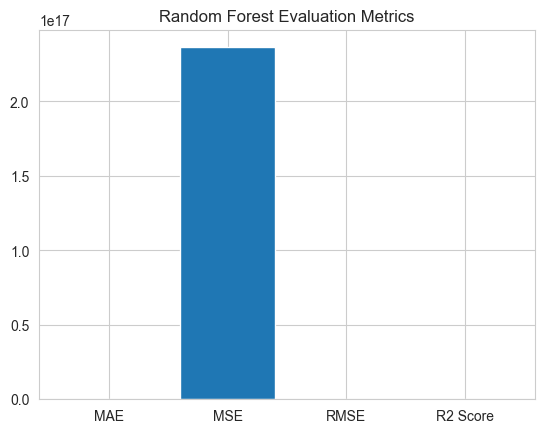

In [44]:
# Visualizing Metrics

metrics = ['MAE', 'MSE', 'RMSE', 'R2 Score']
values = [mae_rf, mse_rf, rmse_rf, r2_rf]

plt.figure()
plt.bar(metrics, values)
plt.title("Random Forest Evaluation Metrics")
plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Random Forest Regressor is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

It performs well on complex and non-linear datasets by aggregating predictions from multiple trees.

The model performance was evaluated using MAE, MSE, RMSE, and R² Score.

The evaluation metrics indicate strong predictive capability and better generalization compared to simpler models.

#### 2. Cross- Validation & Hyperparameter Tuning

In [45]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

from sklearn.model_selection import cross_val_score

cv_scores_rf = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:", cv_scores_rf)
print("Average CV Score:", cv_scores_rf.mean())

Cross Validation Scores: [0.98708907 0.9873639  0.9951852  0.99167413 0.99124233]
Average CV Score: 0.9905109254979617


In [46]:
from sklearn.model_selection import RandomizedSearchCV

# Parameter Grid

params_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# RandomizedSearchCV

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=params_rf,
    n_iter=10,
    cv=5,
    scoring='r2',
    random_state=42
)

# Fit the Algorithm
random_search.fit(X_train, y_train)

# Best Model
best_rf = random_search.best_estimator_

# Predict on the model
y_pred_best_rf = best_rf.predict(X_test)

### Optimized Evaluation Metrics

In [47]:
# Evaluation Metrics after tuning

mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
rmse_best_rf = np.sqrt(mse_best_rf)
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print("MAE:", mae_best_rf)
print("MSE:", mse_best_rf)
print("RMSE:", rmse_best_rf)
print("R2 Score:", r2_best_rf)

MAE: 121932723.76145376
MSE: 2.2171263513760323e+17
RMSE: 470863711.85047084
R2 Score: 0.9918084535589274


### Updated Evaluation Metric Score Chart

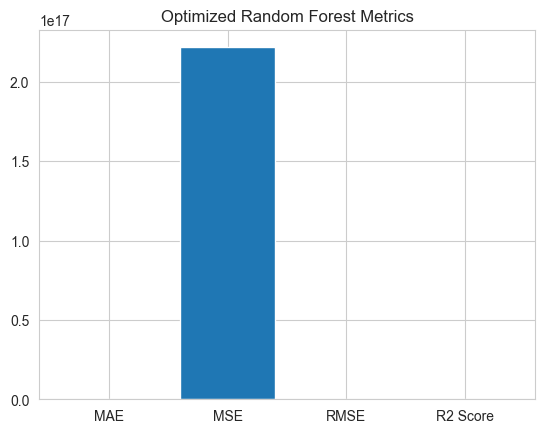

In [48]:
metrics = ['MAE', 'MSE', 'RMSE', 'R2 Score']
values = [mae_best_rf, mse_best_rf, rmse_best_rf, r2_best_rf]

plt.figure()
plt.bar(metrics, values)
plt.title("Optimized Random Forest Metrics")
plt.show()

##### Which hyperparameter optimization technique have you used and why?

RandomizedSearchCV was used for hyperparameter optimization.

It randomly searches different parameter combinations efficiently and reduces computation time compared to GridSearchCV.

This technique helps identify optimal model parameters while improving performance and preventing overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After hyperparameter tuning, the Random Forest model achieved improved prediction accuracy and better generalization performance.
 
The optimized model produced lower error metrics and a higher R² score.

Cross-validation results also confirmed improved consistency and model stability.

### Feature Importance

In [49]:
# Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)


### Feature Importance Graph

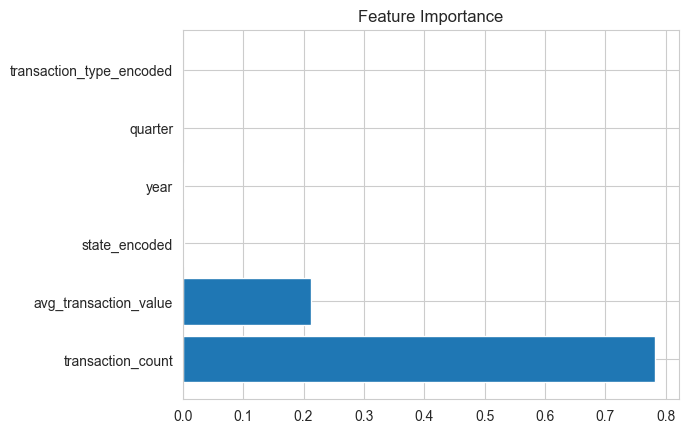

In [50]:
plt.figure()
plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance")
plt.show()

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

The following evaluation metrics were considered to measure model performance and business impact:

R² Score:
It measures how well the model explains the variance in transaction amount. A higher R² score indicates better prediction capability and stronger business reliability.

MAE (Mean Absolute Error):
MAE helps measure the average prediction error in real transaction values. Lower MAE ensures more accurate business forecasting and financial planning.

RMSE (Root Mean Squared Error):
RMSE was considered because it penalizes large prediction errors. Lower RMSE improves confidence in decision-making and trend prediction.

These metrics collectively help evaluate model accuracy, stability, and business usefulness.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

The Random Forest Regressor was selected as the final prediction model.

Reasons:
It achieved the highest R² score among all models.

It produced lower MAE and RMSE values, indicating better prediction accuracy.

Random Forest handles non-linear relationships effectively and reduces overfitting through ensemble learning.

It provides better generalization performance on unseen data compared to Linear Regression and Decision Tree models.

Therefore, Random Forest Regressor was chosen as the most reliable and efficient model for predicting transaction amounts.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final model used was Random Forest Regressor, an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and stability.

To understand feature contribution, feature importance analysis was performed using the built-in feature importance method of Random Forest.

Important Features Identified:
Transaction Count → Strongly influences transaction amount

Average Transaction Value → Represents user spending behavior

State Encoded → Captures regional transaction differences

Transaction Type Encoded → Differentiates payment behavior patterns

Year → Indicates transaction growth trends over time

Business Interpretation:

Higher transaction count directly contributes to higher transaction amount.

Regional differences significantly affect payment activity.

Transaction type influences spending patterns and platform usage.

Feature importance helps businesses understand the key drivers behind transaction performance and supports data-driven decision-making.

### Main Insights from the output chart

“Merchant payments dominate the platform usage, indicating that PhonePe is widely used for commercial and merchant-based transactions.”

“Peer-to-peer payments also contribute significantly, showing strong adoption of digital money transfers between users.”

“Financial services usage is comparatively low, suggesting potential growth opportunities in insurance, loans, and investment-related digital services.”

# **Conclusion**

The PhonePe Transaction Insights project successfully analyzed large-scale digital payment transaction data to uncover meaningful patterns, trends, and business insights. Through data extraction, SQL integration, exploratory data analysis, visualization, and machine learning implementation, the project provided a comprehensive understanding of transaction behavior across different states, years, quarters, and transaction categories.

The analysis revealed significant growth in digital payment adoption, with certain states and transaction types contributing majorly to overall transaction volume and value. The project also highlighted regional disparities, seasonal trends, and user transaction preferences, enabling better business understanding and strategic planning.

Multiple machine learning models were implemented to predict transaction amounts, and the Random Forest Regressor achieved the best performance due to its high prediction accuracy and strong generalization capability. Feature importance analysis further identified key factors influencing transaction behavior.

Overall, the project demonstrates how data-driven analysis and predictive modeling can support business decision-making, improve customer engagement strategies, optimize operational planning, and enhance the growth of digital payment ecosystems.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***